=== Speeds DataFrame ===
          class           order  max_speed
falcon     bird   falconiformes      398.0
parrot     bird  psittaciformes       24.0
lion     mammal       carnivora       80.2
monkey   mammal        primates        NaN
leopard  mammal       carnivora       58.0

--- Mean speed by class ---
class
bird      211.0
mammal     69.1
Name: max_speed, dtype: float64


=== Original DataFrame ===
  department employee  salary  experience
0         it        a   70000           5
1         it        b   80000           7
2         hr        c   50000           3
3         hr        d   55000           4
4    finance        e   90000           8
5    finance        f   95000          10
6         it        g   75000           6

--- Average Salary by Department ---
department
finance    92500.0
hr         52500.0
it         75000.0
Name: salary, dtype: float64

--- Total Salary by Department ---
department
finance    185000
hr         105000
it         225000
Name: salary, dty

C:\Users\anjan\AppData\Local\Temp\ipykernel_16200\2233505448.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='department', palette='Set2')


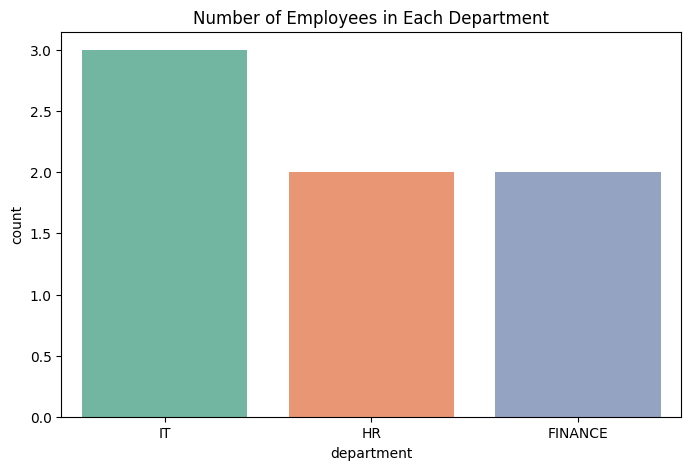

C:\Users\anjan\AppData\Local\Temp\ipykernel_16200\2233505448.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='department', y='salary', estimator='mean', palette='viridis')


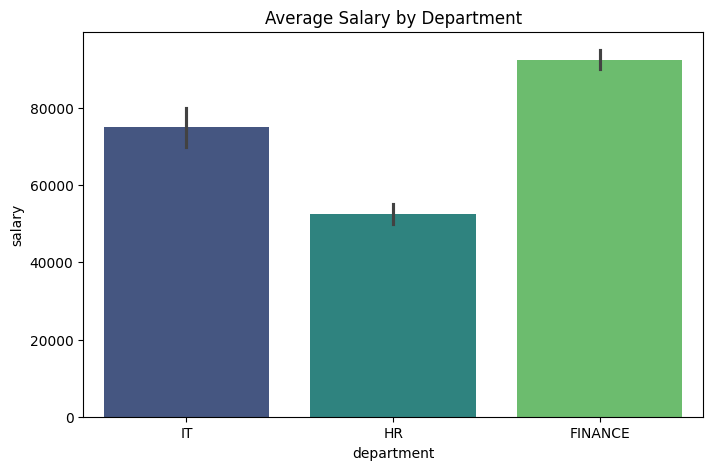

C:\Users\anjan\AppData\Local\Temp\ipykernel_16200\2233505448.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='department', y='salary', palette='coolwarm')


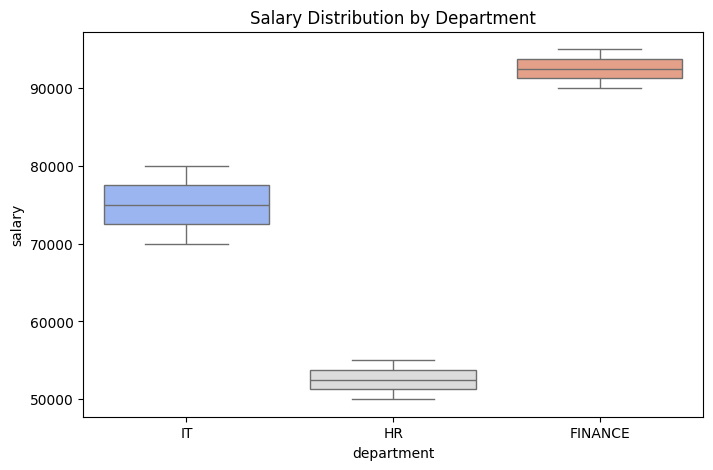

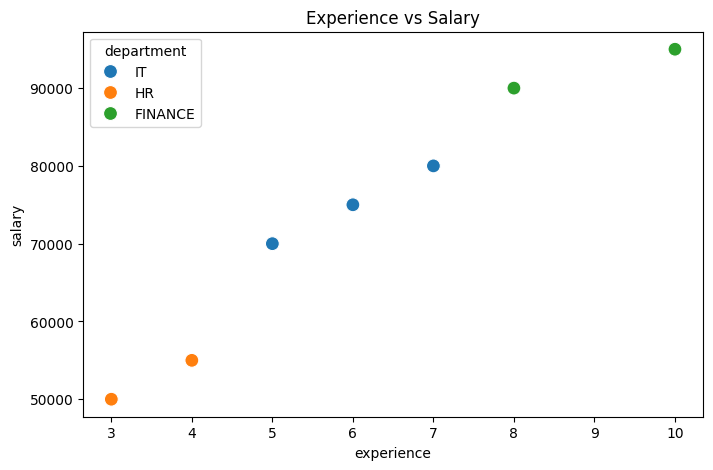

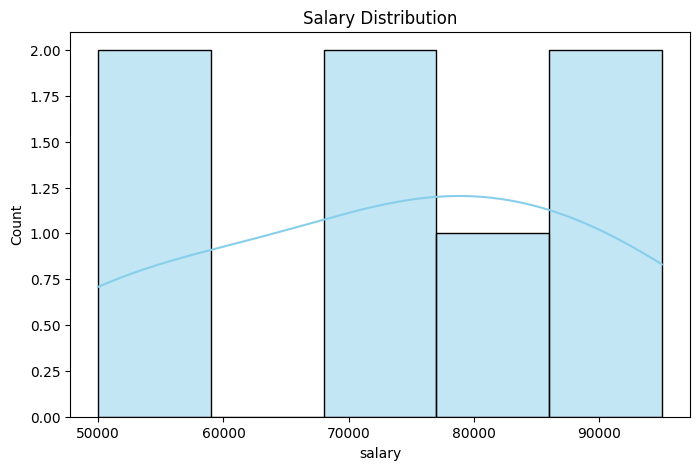

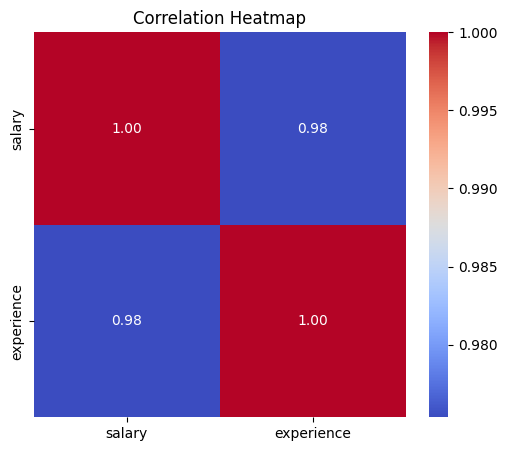

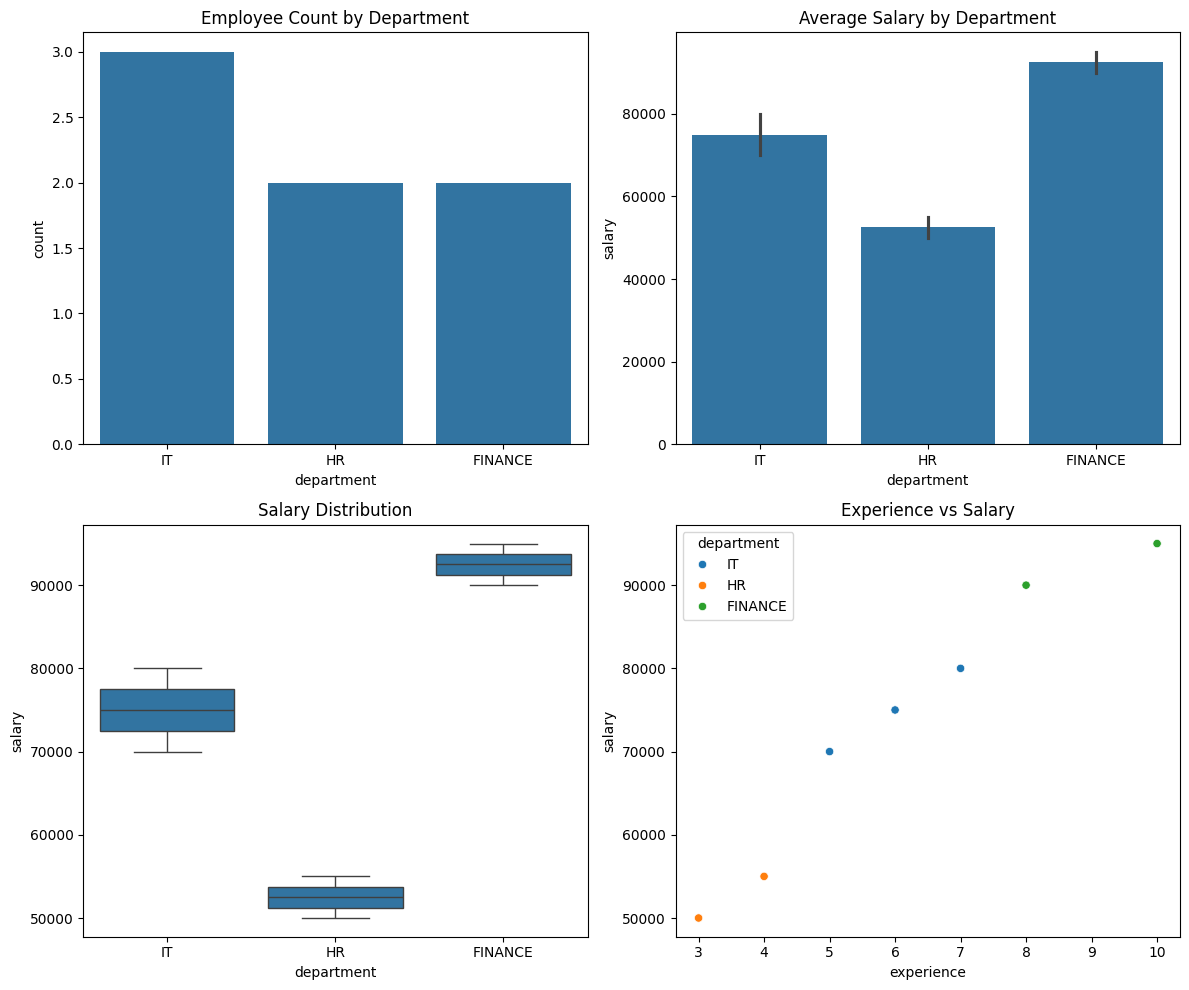

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== PART 1: ADVANCED PANDAS ======================

# --- GROUPBY EXAMPLE ---
speeds = pd.DataFrame(
    [
        ("bird", "falconiformes", 398.0),
        ("bird", "psittaciformes", 24.0),
        ("mammal", "carnivora", 80.2),
        ("mammal", "primates", np.nan),
        ("mammal", "carnivora", 58.0),
    ],
    index=["falcon", "parrot", "lion", "monkey", "leopard"],
    columns=("class", "order", "max_speed"),
)

print("=== Speeds DataFrame ===")
print(speeds)

print("\n--- Mean speed by class ---")
print(speeds.groupby("class")["max_speed"].mean())


# --- MAIN DATAFRAME ---
data = {
    'department': ['it', 'it', 'hr', 'hr', 'finance', 'finance', 'it'],
    'employee': ['a', 'b', 'c', 'd', 'e', 'f', 'g'],
    'salary': [70000, 80000, 50000, 55000, 90000, 95000, 75000],
    'experience': [5, 7, 3, 4, 8, 10, 6]
}

df = pd.DataFrame(data)
print("\n\n=== Original DataFrame ===")
print(df)

# Basic GroupBy + Aggregation
print("\n--- Average Salary by Department ---")
print(df.groupby('department')['salary'].mean())

print("\n--- Total Salary by Department ---")
print(df.groupby('department')['salary'].sum())

print("\n--- Count of Employees by Department ---")
print(df.groupby('department').size())

# Named Aggregation
print("\n--- Named Aggregation ---")
result = df.groupby('department').agg(
    avg_sal=('salary', 'mean'),
    max_sal=('salary', 'max'),
    avg_experience=('experience', 'mean')
)
print(result)

# apply with lambda
df['salary_level'] = df['salary'].apply(lambda x: 'High' if x > 80000 else 'Medium')
print("\n--- After apply with lambda ---")
print(df)


# --- MERGE ---
dept_info = pd.DataFrame({
    'department': ['IT', 'HR', 'Finance'],
    'manager': ['ravi', 'priya', 'suresh'],
    'location': ['hyderabad', 'bangalore', 'chennai']
})

df['department'] = df['department'].str.upper()
dept_info['department'] = dept_info['department'].str.upper()

merged_df = pd.merge(df, dept_info, on='department', how='left')
print("\n--- After Merge ---")
print(merged_df)


# --- PIVOT TABLE ---
pivot_data = {
    'Department': ['IT', 'IT', 'HR', 'HR', 'Finance'],
    'Gender': ['M', 'F', 'M', 'F', 'M'],
    'Salary': [70000, 80000, 50000, 55000, 90000]
}

df2 = pd.DataFrame(pivot_data)

pivot = pd.pivot_table(
    df2,
    values='Salary',
    index='Department',
    columns='Gender',
    aggfunc='mean'
)
print("\n--- Pivot Table ---")
print(pivot)


# ====================== PART 2: VISUALISATION ======================

print("\n\n====================== VISUALISATION ======================")

# Count Plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='department', palette='Set2')
plt.title('Number of Employees in Each Department')
plt.show()

# Bar Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='department', y='salary', estimator='mean', palette='viridis')
plt.title('Average Salary by Department')
plt.show()

# Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='department', y='salary', palette='coolwarm')
plt.title('Salary Distribution by Department')
plt.show()

# Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='experience', y='salary', hue='department', s=100)
plt.title('Experience vs Salary')
plt.show()

# Histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='salary', bins=5, kde=True, color='skyblue')
plt.title('Salary Distribution')
plt.show()

# Heatmap
plt.figure(figsize=(6, 5))
corr = df[['salary', 'experience']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Multiple Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(data=df, x='department', ax=axes[0, 0])
axes[0, 0].set_title('Employee Count by Department')

sns.barplot(data=df, x='department', y='salary', estimator='mean', ax=axes[0, 1])
axes[0, 1].set_title('Average Salary by Department')

sns.boxplot(data=df, x='department', y='salary', ax=axes[1, 0])
axes[1, 0].set_title('Salary Distribution')

sns.scatterplot(data=df, x='experience', y='salary', hue='department', ax=axes[1, 1])
axes[1, 1].set_title('Experience vs Salary')

plt.tight_layout()
plt.show()